# 07 - Inference Testing on Unseen Images (50 Epochs Model)
## Proyek: RoadDamage_AI

### Tujuan Pengujian Inference
1. Menguji model terlatih `road_damage.pt` (50-epoch best model) pada gambar baru dari **Test Set (10% unseen data)**.
2. Memvisualisasikan deteksi bounding box, nama kelas, dan confidence score.
3. Mengukur kecepatan waktu inferensi (*latency*) dan FPS real-time.


In [1]:
%matplotlib inline
import os
import glob
import time
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

MODEL_PATH = os.path.abspath("../backend/models/road_damage.pt")
TEST_IMAGES_DIR = os.path.abspath("../data/test/images")
test_images = sorted(glob.glob(os.path.join(TEST_IMAGES_DIR, "*.jpg")))

print(f"Model Path: {MODEL_PATH}")
print(f"Total Gambar Uji (Test Set): {len(test_images)}")


Model Path: z:\Projects\RoadDamage_AI\backend\models\road_damage.pt
Total Gambar Uji (Test Set): 202


---
### 1. Load Model 50-Epoch Terlatih


In [2]:
model = YOLO(MODEL_PATH)
print(f"Model {model.model_name} berhasil dimuat!")


Model z:\Projects\RoadDamage_AI\backend\models\road_damage.pt berhasil dimuat!


---
### 2. Inferensi pada Sampel Gambar Test Set (Unseen)


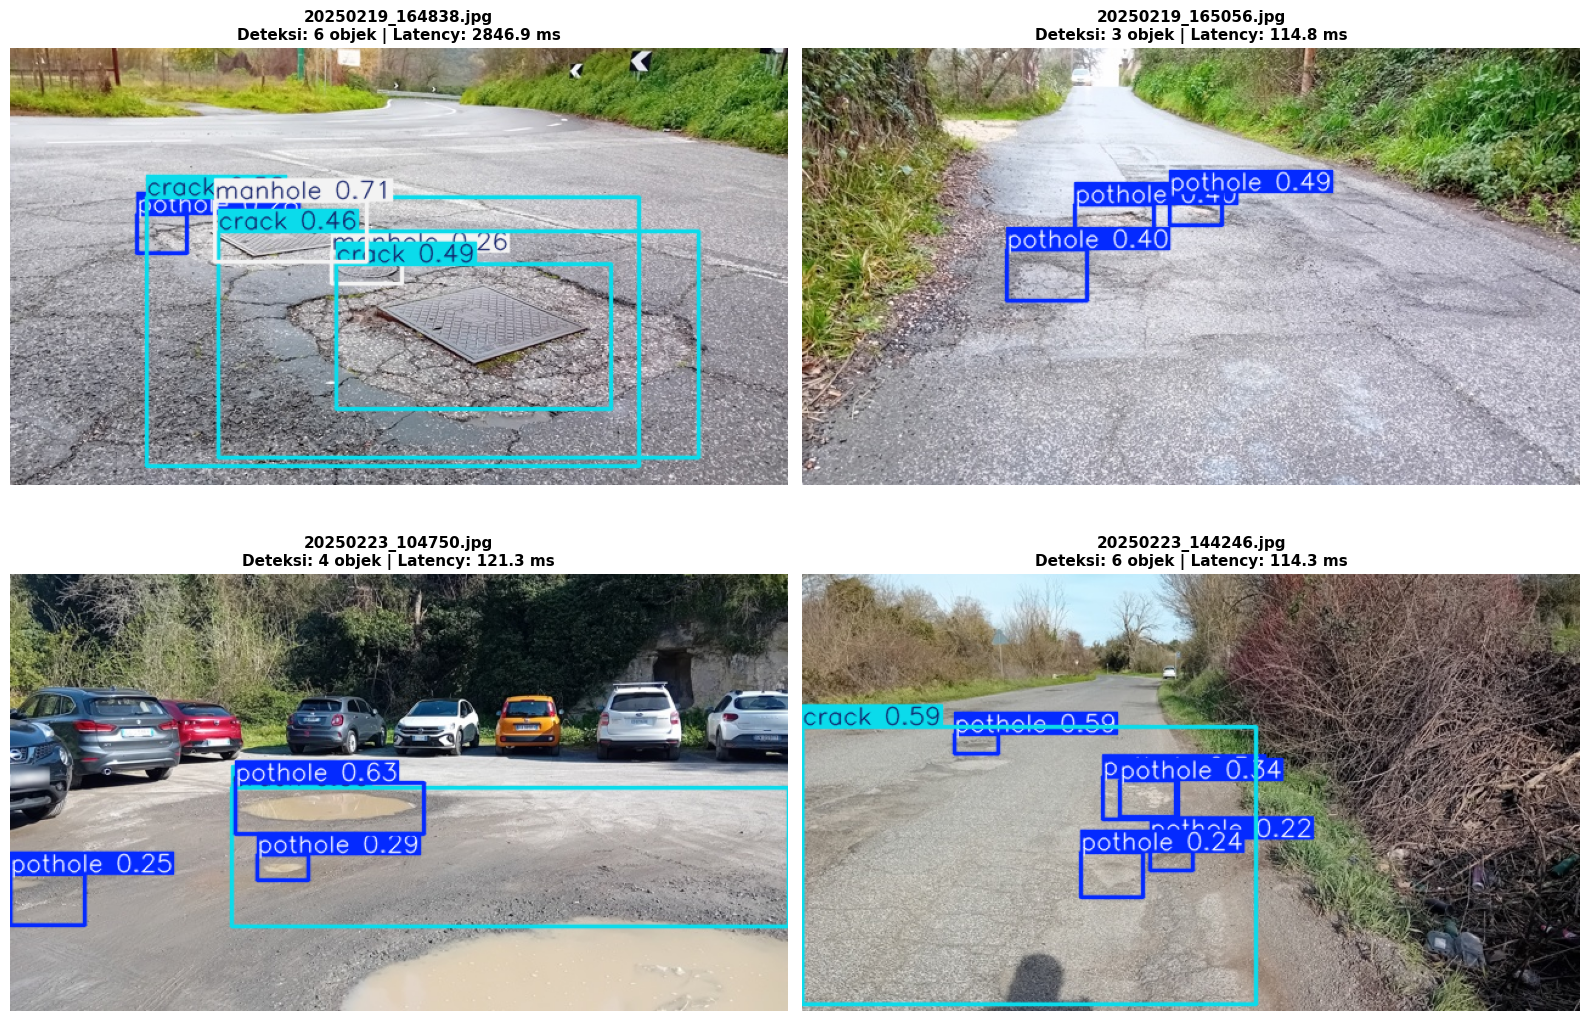

In [3]:
sample_candidates = [
    os.path.join(TEST_IMAGES_DIR, "20250219_164838.jpg"),
    os.path.join(TEST_IMAGES_DIR, "20250219_165056.jpg"),
    os.path.join(TEST_IMAGES_DIR, "20250223_104750.jpg"),
    os.path.join(TEST_IMAGES_DIR, "20250223_144246.jpg")
]
sample_test_images = [p for p in sample_candidates if os.path.exists(p)]
if len(sample_test_images) < 4:
    sample_test_images = test_images[:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for idx, img_p in enumerate(sample_test_images):
    t0 = time.time()
    results = model.predict(source=img_p, conf=0.20, verbose=False)
    infer_time_ms = (time.time() - t0) * 1000
    
    annotated_bgr = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    
    num_det = len(results[0].boxes)
    img_name = os.path.basename(img_p)
    
    axes[idx].imshow(annotated_rgb)
    axes[idx].set_title(f"{img_name}\nDeteksi: {num_det} objek | Latency: {infer_time_ms:.1f} ms", fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


---
### 3. Analisis Kecepatan Inferensi (Benchmark FPS)


In [4]:
latencies = []

for img_p in test_images[:20]:
    t0 = time.time()
    _ = model.predict(source=img_p, conf=0.20, verbose=False)
    latencies.append((time.time() - t0) * 1000)

avg_latency = sum(latencies) / len(latencies)
fps = 1000 / avg_latency

print(f"Rata-rata Waktu Inferensi : {avg_latency:.2f} ms per gambar")
print(f"Estimasi Throughput       : {fps:.1f} FPS")


Rata-rata Waktu Inferensi : 102.37 ms per gambar
Estimasi Throughput       : 9.8 FPS
